In [2]:
import pandas as pd
import numpy as np

In [3]:
import pandas as pd

file_path = "data_broyeur.xlsx"

#  Lire le fichier avec multi-header (3 lignes)
df = pd.read_excel(file_path, header=[0,1,2])

#  Créer des noms “normaux” → garder seulement la partie qui contient le vrai nom
# ici, on prend le dernier niveau non vide si le premier est "Unnamed"
def clean_col(col):
    # col est un tuple de 3 niveaux
    # on prend le dernier qui n'est pas nan et ne commence pas par "Unnamed"
    for x in reversed(col):
        if str(x) != 'nan' and not str(x).startswith('Unnamed'):
            return str(x).strip()
    return str(col[-1]).strip()  # fallback

df.columns = [clean_col(col) for col in df.columns]

#  Vérifier
print(df.columns.tolist())

['Date', 'Run time', 'MM ready', 'MM online', 'MM utilization KPI', 'MM optimization KPI', 'Mill feed (Bit 0)', 'Fineness (Bit 1)', 'Hydraulic pressure (Bit 2)', 'Mill gas flow (Bit 3)', 'SO3 / Gypsum (Bit 4)', 'LOI / Limestone (Bit 5)', 'Lab1 / MIC1 (bit 6)', 'Lab2 / MIC2 (Bit 7)', 'Lab3 / MIC3 (Bit 8)', 'Lab4 / MIC4 (Bit 9)', 'Lab5 / MIC5 (Bit 10)', 'Lab6 / MIC6 (Bit 11)', 'Lab7 / MIC7 (Bit 12)', 'Lab8 / MIC8 (Bit 13)']


In [4]:
# supprimer lignes vides
df = df.dropna(how="all")

# remplacer toutes les valeurs non numériques par NaN
df["MM utilization KPI"] = pd.to_numeric(df["MM utilization KPI"], errors='coerce')
df["MM optimization KPI"] = pd.to_numeric(df["MM optimization KPI"], errors='coerce')
df["Mill feed (Bit 0)"] = pd.to_numeric(df["Mill feed (Bit 0)"], errors='coerce')
df["Fineness (Bit 1)"] = pd.to_numeric(df["Fineness (Bit 1)"], errors='coerce')
#df["Hydraulic pressure (Bit 2)"] = pd.to_numeric(df["Hydraulic pressure (Bit 2)"], errors='coerce')
#df["Mill gas flow (Bit 3)"] = pd.to_numeric(df["Mill gas flow (Bit 3)"], errors='coerce')
# supprimer valeurs manquantes critiques
df = df.dropna(subset=[
    "MM utilization KPI",
    "Mill feed (Bit 0)",
    "Hydraulic pressure (Bit 2)",
    "Mill gas flow (Bit 3)"
])

In [5]:
# Sélection des variables utiles
features = [
    "MM utilization KPI",
    "MM optimization KPI",
    "Mill feed (Bit 0)",
    "Fineness (Bit 1)",
    "Hydraulic pressure (Bit 2)",
    "Mill gas flow (Bit 3)"
]
df = df[features]
df.head()


,MM utilization KPI,MM optimization KPI,Mill feed (Bit 0),Fineness (Bit 1),Hydraulic pressure (Bit 2),Mill gas flow (Bit 3)
1,100.0,33.33,100.00,100.0,0,0
2,100.0,33.33,100.00,100.0,0,0
3,100.0,33.33,100.00,100.0,0,0
4,100.0,33.33,100.00,100.0,0,0
5,80.0,33.33,73.33,100.0,0,0


In [6]:
print(df["Hydraulic pressure (Bit 2)"].dtype)
print(df["Hydraulic pressure (Bit 2)"].head())

object
1    0
2    0
3    0
4    0
5    0
Name: Hydraulic pressure (Bit 2), dtype: object


In [7]:
# =========================
# 4. Feature engineering
# =========================

# variation pression
df["pressure_change"] = df["Hydraulic pressure (Bit 2)"].diff()

# variation gas flow
df["gasflow_change"] = df["Mill gas flow (Bit 3)"].diff()

# variation feed
df["feed_change"] = df["Mill feed (Bit 0)"].diff()

# moyenne mobile pression
df["pressure_mean5"] = df["Hydraulic pressure (Bit 2)"].rolling(5).mean()

# moyenne mobile gas flow
df["gasflow_mean5"] = df["Mill gas flow (Bit 3)"].rolling(5).mean()

df = df.dropna()


In [8]:
#Création intelligente du label Overload de surcharge (l'output du model ) 1 == surcharge détectée 0 == non surcharge
# seuils statistiques
#pressure_threshold = df["Hydraulic pressure (Bit 2)"].quantile(0.90)
#gasflow_threshold = df["Mill gas flow (Bit 3)"].quantile(0.90)
"""til_threshold = df["MM utilization KPI"].quantile(0.70)   # au lieu de 0.85
optimi = df["MM optimization KPI"].quantile(0.50)          # au lieu de 0.75
millfeed = df["Mill feed (Bit 0)"].quantile(0.70)          # au lieu de 0.90
finess = df["Fineness (Bit 1)"].quantile(0.70)             # au lieu de 0.90"""
util_threshold = 90
optimi = 30
millfeed = 80
finess = 80
	

# règle combinée surcharge
df["Overload"] = (
    #(df["Hydraulic pressure (Bit 2)"] > pressure_threshold) &
    #(df["Mill gas flow (Bit 3)"] > gasflow_threshold) &
    (df["MM utilization KPI"] > util_threshold) &
    (df["MM optimization KPI"] > optimi) &
    (df["Mill feed (Bit 0)"] > millfeed) &
    (df["Fineness (Bit 1)"] > finess)
    
    
).astype(int)
df.head(90)

,MM utilization KPI,MM optimization KPI,Mill feed (Bit 0),Fineness (Bit 1),Hydraulic pressure (Bit 2),Mill gas flow (Bit 3),pressure_change,gasflow_change,feed_change,pressure_mean5,gasflow_mean5,Overload
5,80.0,33.33,73.33,100.0,0,0,0,0,-26.67,0.0,0.0,0
6,90.0,33.33,86.67,100.0,0,0,0,0,13.34,0.0,0.0,0
7,25.0,33.33,0.00,100.0,0,0,0,0,-86.67,0.0,0.0,0
13,100.0,0.00,100.00,100.0,0,0,0,0,100.00,0.0,0.0,0
14,100.0,0.00,100.00,100.0,0,0,0,0,0.00,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
113,100.0,33.33,100.00,100.0,0,0,0,0,0.00,0.0,0.0,1
114,100.0,33.33,100.00,100.0,0,0,0,0,0.00,0.0,0.0,1
115,100.0,33.33,100.00,100.0,0,0,0,0,0.00,0.0,0.0,1
116,100.0,33.33,100.00,100.0,0,0,0,0,0.00,0.0,0.0,1


**explication**
df["Hydraulic pressure (Bit 2)"].quantile(0.90) → calcule la valeur qui sépare les 10 % les plus élevées de toutes les mesures de pression.

Autrement dit, 90 % des valeurs sont en dessous de ce seuil, et 10 % sont au-dessus.

Même logique pour le débit de gaz et l’indicateur de performance (MM utilization KPI), avec 85 % pour ce dernier.

L’idée : définir des seuils “anormaux” ou critiques” à partir des statistiques du dataset, plutôt que de mettre un nombre arbitraire.

**principe**
Explications :

(df["Hydraulic pressure (Bit 2)"] > pressure_threshold)
→ True pour toutes les lignes où la pression dépasse le seuil critique.

(df["Mill gas flow (Bit 3)"] > gasflow_threshold)
→ True pour toutes les lignes où le flux de gaz dépasse le seuil critique.

(df["MM utilization KPI"] > util_threshold)
→ True pour toutes les lignes où l’utilisation dépasse le seuil critique.

& → ET logique

Seules les lignes où les 3 conditions sont vraies en même temps seront considérées comme surcharge.

.astype(int) → convertit True/False en 1/0

1 → surcharge détectée

0 → pas de surcharge

In [9]:
#Vérification du dataset
print("Dataset shape:", df.shape)
print("\nDistribution Overload:")
print(df["Overload"].value_counts())

print("\nPreview dataset:")
print(df.head())

Dataset shape: (6719, 12)

Distribution Overload:
Overload
0    5856
1     863
Name: count, dtype: int64

Preview dataset:
    MM utilization KPI  MM optimization KPI  Mill feed (Bit 0)  \
5                 80.0                33.33              73.33   
6                 90.0                33.33              86.67   
7                 25.0                33.33               0.00   
13               100.0                 0.00             100.00   
14               100.0                 0.00             100.00   

    Fineness (Bit 1) Hydraulic pressure (Bit 2) Mill gas flow (Bit 3)  \
5              100.0                          0                     0   
6              100.0                          0                     0   
7              100.0                          0                     0   
13             100.0                          0                     0   
14             100.0                          0                     0   

   pressure_change gasflow_change  feed_c

In [10]:
# =========================
# 7. Sauvegarder la base finale
# =========================

df.to_csv("mill_overload_dataset.csv", index=False)

print("\nDataset prêt pour le modèle.")


Dataset prêt pour le modèle.


**Code Python : modèle XGBoost**

In [11]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [13]:
# =========================
# 1. Charger dataset préparé
# =========================

df = pd.read_csv("mill_overload_dataset.csv")


In [14]:
# =========================
# 2. Séparer X et y
# =========================

X = df.drop("Overload", axis=1)
y = df["Overload"]


In [25]:
# =========================
# 3. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
y_test

3551    0
3105    0
549     0
1163    0
1881    0
       ..
172     1
3827    0
4334    0
422     0
1650    0
Name: Overload, Length: 1344, dtype: int64

In [16]:
# =========================
# 4. Création modèle XGBoost
# =========================

model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

In [17]:
# =========================
# 5. Entraînement
# =========================

model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, ...)

In [18]:
# =========================
# 6. Prédictions
# =========================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]


In [23]:
y_pred[0]

np.int64(0)

In [20]:
# =========================
# 7. Evaluation
# =========================

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9992559523809523

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1164
           1       0.99      1.00      1.00       180

    accuracy                           1.00      1344
   macro avg       1.00      1.00      1.00      1344
weighted avg       1.00      1.00      1.00      1344



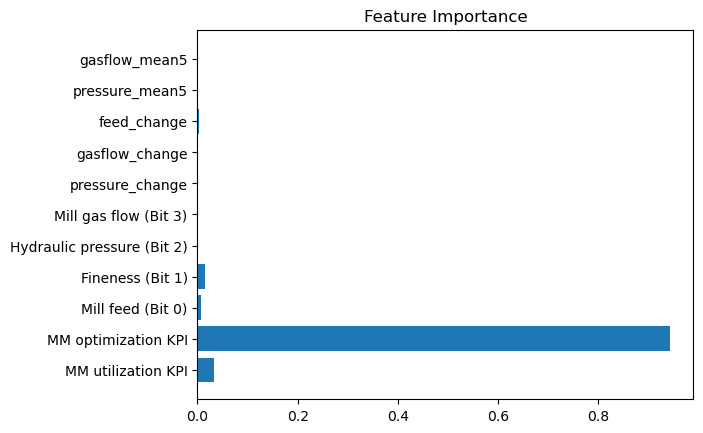

In [21]:
# =========================
# 8. Importance des variables
# =========================

import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()